Car Price Prediction with Machine Learning

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Load Dataset

In [2]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Dataset Information

In [3]:
print("Shape :", df.shape)
df.info()

Shape : (301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Check Missing Values

In [4]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Feature Engineering

Calculate Car Age

In [5]:
df['Car_Age'] = 2025 - df['Year']
df.drop(['Year'], axis=1, inplace=True)
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


Visualization

Car Age vs Selling Price

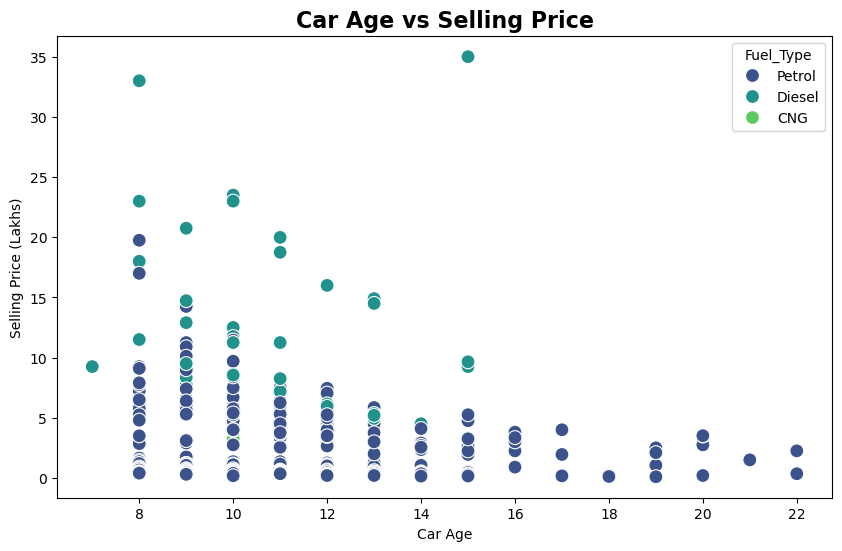

In [6]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Car_Age',
    y='Selling_Price',
    data=df,
    hue='Fuel_Type',
    palette='viridis',
    s=100
)

plt.title("Car Age vs Selling Price", fontsize=16, fontweight='bold')
plt.xlabel("Car Age")
plt.ylabel("Selling Price (Lakhs)")
plt.show()

Fuel Type Distribution

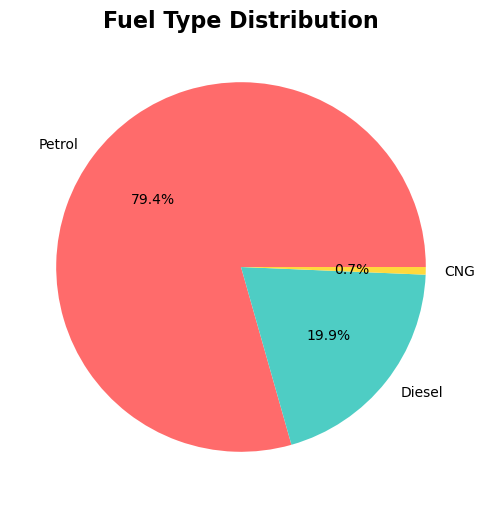

In [7]:
plt.figure(figsize=(8,6))

colors = ['#FF6B6B','#4ECDC4','#FFD93D']

df['Fuel_Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors
)

plt.title("Fuel Type Distribution", fontsize=16, fontweight='bold')
plt.ylabel("")
plt.show()

Correlation Heatmap

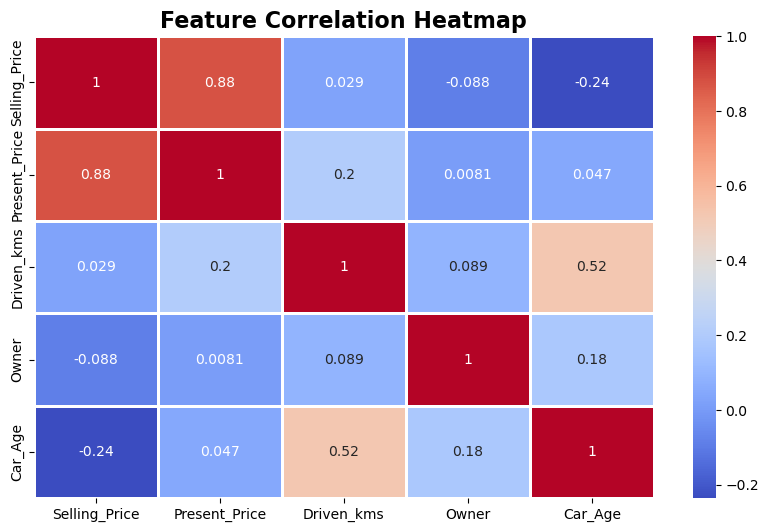

In [8]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.show()

Convert Categorical Data

In [9]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,4.75,9.54,43000,0,12,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,7.25,9.85,6900,0,8,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2.85,4.15,5200,0,14,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,4.60,6.87,42450,0,11,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


Define Features and Target

In [10]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [12]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [13]:
y_pred = model.predict(X_test)

Model Evaluation

In [14]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,2))

MAE : 0.62
RMSE : 0.94
R2 Score : 0.96


Actual vs Predicted Chart

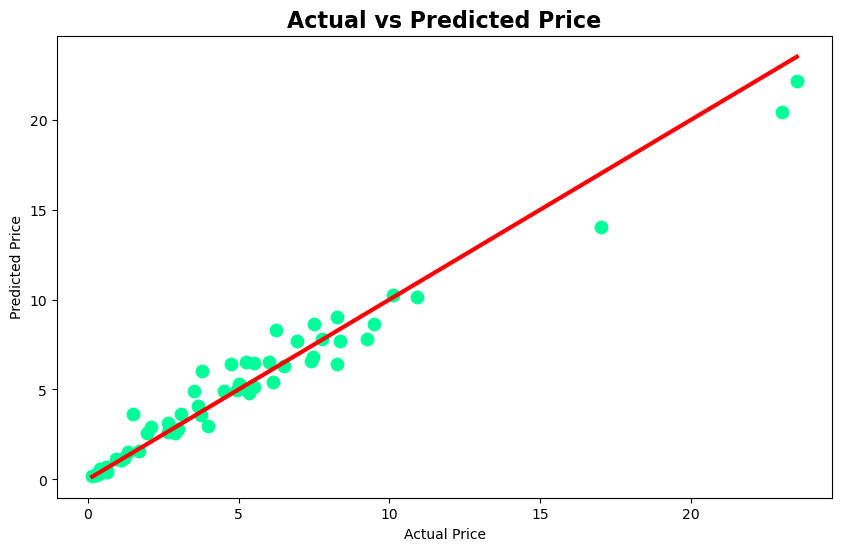

In [15]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    color='#00FF99',
    s=80
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=3
)

plt.title("Actual vs Predicted Price", fontsize=16, fontweight='bold')

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.show()

Feature Importance

In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                     Feature  Importance
0              Present_Price    0.878725
3                    Car_Age    0.055125
1                 Driven_kms    0.031992
104      Transmission_Manual    0.005815
91     Car_Name_land cruiser    0.004897
72             Car_Name_city    0.003617
84         Car_Name_fortuner    0.003398
103  Selling_type_Individual    0.003042
74    Car_Name_corolla altis    0.003040
101         Fuel_Type_Diesel    0.002821


Predict New Car Price

In [17]:
sample = X.iloc[0:1]
prediction = model.predict(sample)
print("Predicted Price =", round(prediction[0],2), "Lakhs")

Predicted Price = 3.77 Lakhs
